# Tuning BP parameters programmatically

The process will evaluate find the best combination of `ms_scaling_factor` and `max_iter`.
- ms_scaling_factor: selecting between 0 and 1.0, a total of 10 choices.
- max_iter: selecting from $\{ 1~10, 16, 20, 50, 100, 200, 500, 1000 \}$, a total of 17 choices
The total number of choices is then 10 * 17 = 17, still quite expensive so it's better to run only on a few configs.

We need to reduce the number of samples to reach a fair comparison.
To do this, we ensure that all decoders will use exactly the same set of syndrome to evaluate.

To execute this notebook with a custom code, noise and decoder, use
```sh
# srun --time=1-00:00:00 --mem=10G --cpus-per-task=2 \
python3 -m qec_lego_bench notebook-bp-tuner ./bp_tuner_example.ipynb 'rsc(d=3,p=0.01)' --decoder 'bposd'
```

In [1]:
code: str = "rsc(d@3,p@0.01)"
noise: str = "none"
decoder: str = "bposd"

# ms_scaling_factor_choices: list[float] = [0.5, 0.625, 0.8, 1.0]
ms_scaling_factor_choices: list[float] = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
max_iter_choices: list[int] = list(range(1, 11)) + [16, 20, 50, 100, 200, 500, 1000]

max_cpu_hours: float = None
target_precision: float = 0.04  # about 4000 errors for the configuration with the smallest 

slurm_maximum_jobs: int = 50  # start with a smaller number of workers to avoid resource waste
slurm_cores_per_node: int = 10  # (slurm_maximum_jobs // slurm_cores_per_node) should not exceed 200
slurm_mem_per_job: int = 4  # 4GB per job
slurm_extra: dict = dict(
    walltime = "1-00:00:00",  # adaptively shutdown if no more jobs
    queue = "scavenge",  # use with caution: dask does not seem to handle scavenge workers well
    job_extra_directives = ["--requeue"],  # use with scavenge partition will help spawn scavenged jobs
)
target_job_time: float = 60 * 3

json_filename: str = None
force_finished: bool = False  # only plot the figure and do not run experiments

In [2]:
# Parameters
code = "cbb(n@90,k@8,d@10)"
noise = "flip(p@0.001)"
decoder = "bposd"
json_filename = "circuit-cbb.py.bp-tuner.bposd.json"
target_precision = 0.04


In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
code = code.replace("@", "=")
noise = noise.replace("@", "=")
decoder = decoder.replace("@", "=")

from qec_lego_bench.notebooks.bp_tuner import *

if json_filename is None:
    json_filename = default_json_filename(code=code, noise=noise, decoder=decoder)
print("saving results to:", json_filename)


saving results to: circuit-cbb.py.bp-tuner.bposd.json


### Define the Monte Carlo job function

In [5]:
jobs = [MonteCarloJob(code=code, noise=noise, decoder=decoder)]

monte_carlo_function = BPTunerMonteCarloFunction(
    max_iter_choices=max_iter_choices,
    ms_scaling_factor_choices=ms_scaling_factor_choices,
)

if not force_finished:
    print(monte_carlo_function(10, code=code, noise=noise, decoder=decoder, verbose=True))

Writing Circuit file to /tmp/tmp2edyf7h1/tmp.stim
Writing DEM file to /tmp/tmp2edyf7h1/tmp.dem
Writing detectors to /tmp/tmp2edyf7h1/tmp.det.b8 and observables to /tmp/tmp2edyf7h1/tmp.obs.b8


0it [00:00, ?it/s]

1it [00:00,  6.20it/s]

2it [00:00,  7.61it/s]

3it [00:00,  6.07it/s]

...

168it [00:35,  1.79it/s]

169it [00:35,  2.37it/s]

170it [00:35,  3.04it/s]

170it [00:35,  4.80it/s]

(10, MultiDecoderLogicalErrorRates(results={'bposd(max_iter=1,ms_scaling_factor=0.1)': LogicalErrorResult(errors=2, discards=0, panic_cases=None, elapsed=None), 'bposd(max_iter=1,ms_scaling_factor=0.2)': LogicalErrorResult(errors=0, discards=0, panic_cases=None, elapsed=None), 'bposd(max_iter=1,ms_scaling_factor=0.3)': LogicalErrorResult(errors=0, discards=0, panic_cases=None, elapsed=None), 'bposd(max_iter=1,ms_scaling_factor=0.4)': LogicalErrorResult(errors=0, discards=0, panic_cases=None, elapsed=None), 'bposd(max_iter=1,ms_scaling_factor=0.5)': LogicalErrorResult(errors=0, discards=0, panic_cases=None, elapsed=None), 'bposd(max_iter=1,ms_scaling_factor=0.6)': LogicalErrorResult(errors=0, discards=0, panic_cases=None, elapsed=None), 'bposd(max_iter=1,ms_scaling_factor=0.7)': LogicalErrorResult(errors=0, discards=0, panic_cases=None, elapsed=None), 'bposd(max_iter=1,ms_scaling_factor=0.8)': LogicalErrorResult(errors=0, discards=0, panic_cases=None, elapsed=None), 'bposd(max_iter=1,ms

### Define the strategy to submit jobs

In [6]:
precision_submitter = PrecisionSubmitter(
    time_limit=max_cpu_hours * 3600 if max_cpu_hours is not None else None,
    min_precision=None,
    target_precision=target_precision,
)

def submitter(executor: MonteCarloJobExecutor) -> list[tuple[MonteCarloJob, int]]:
    submit = precision_submitter(executor)
    return submit

## The rest of the notebook runs the evaluation

In [7]:
config = MonteCarloExecutorConfig(target_job_time=target_job_time)
config.max_submitted_job = max(config.max_submitted_job, 3 * slurm_maximum_jobs)
executor = MonteCarloJobExecutor(
    monte_carlo_function,
    jobs,
    config=config,
    filename=json_filename,
    result_type=MultiDecoderLogicalErrorRates,
)

client_connector = SlurmClientConnector(
    slurm_maximum_jobs=slurm_maximum_jobs,
    slurm_cores_per_node=slurm_cores_per_node,
    slurm_mem_per_job=slurm_mem_per_job,
    slurm_extra=slurm_extra,
)

,Status,JobKey,Job,Finished,Pending,Submitted,1000 jobs,Total,Duration,Errors,Discards,Panics,Error Rate
0,pending,ab7dee,"Job(code=cbb(n=90,k=8,d=10), noise=flip(p=0.001), decoder=bposd)",207827 (6%),2800260 (93%),71076 (2%),1000 (100%),3008087,515674.0s (8594.6min),301,0,0,0.0014(2)


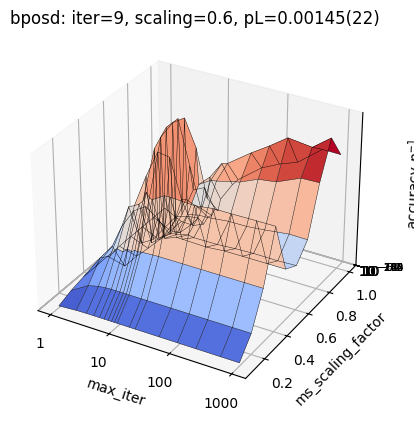

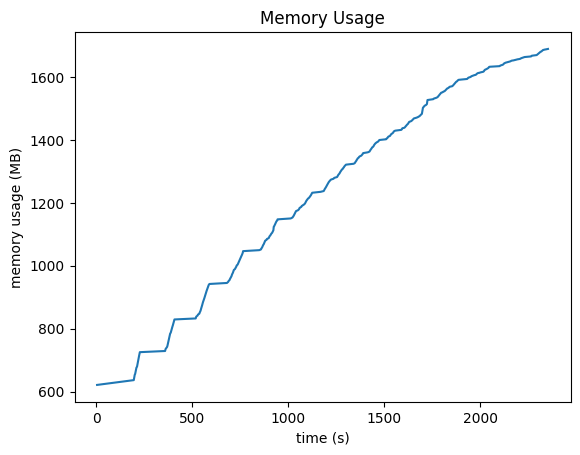

winding up a new client


#!/usr/bin/env bash

#SBATCH -J dask-worker
#SBATCH -p scavenge
#SBATCH -n 1
#SBATCH --cpus-per-task=10
#SBATCH --mem=38G
#SBATCH -t 1-00:00:00
#SBATCH --out="/gpfs/gibbs/project/lin_zhong/yw729/PaperMWPFEvaluation/accuracy/circuit-cbb/slurm_job/%j.out"
#SBATCH --error="/gpfs/gibbs/project/lin_zhong/yw729/PaperMWPFEvaluation/accuracy/circuit-cbb/slurm_job/%j.err"
#SBATCH --requeue

/home/yw729/.conda/envs/qec/bin/python -m distributed.cli.dask_worker tcp://10.181.172.27:36311 --name dummy-name --nthreads 1 --memory-limit 3.73GiB --nworkers 10 --nanny --death-timeout 60

cluster dashboard link: http://10.181.172.27:8787/status


In [8]:
import time  # add some sleep to let them work properly in VScode Jupyter notebook

time.sleep(0.2)
progress_plotter = JobProgressPlotter()
time.sleep(0.2)
bp_tuner_plotter = BPTunerPlotter(
    max_iter_choices=max_iter_choices,
    ms_scaling_factor_choices=ms_scaling_factor_choices,
)
time.sleep(0.2)
memory_plotter = MemoryUsagePlotter()


def callback(executor: MonteCarloJobExecutor):
    progress_plotter(executor)
    time.sleep(0.1)
    bp_tuner_plotter(executor)
    time.sleep(0.1)
    memory_plotter(executor)
    time.sleep(0.1)


executor.execute(
    client_connector=client_connector,
    submitter=submitter,
    loop_callback=callback,
    shutdown_cluster=True,
    force_finished=force_finished,
)